In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("tested.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [7]:
#PREPROCESSING / CLEANING

# Remove Unwanted features
df.drop(["Cabin", "PassengerId","Fare","Ticket", "Name"], axis=1, inplace=True)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,34.5,0,0,Q
1,1,3,female,47.0,1,0,S
2,0,2,male,62.0,0,0,Q
3,0,3,male,27.0,0,0,S
4,1,3,female,22.0,1,1,S


In [9]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Embarked,0


In [10]:
df["Age"].value_counts()

,count
Age,
21.0,17
24.0,17
22.0,16
30.0,15
18.0,13
...,...
44.0,1
5.0,1
51.0,1


In [11]:
#Replace null with median
df.fillna(df["Age"].median(), axis=1, inplace=True)

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,34.5,0,0,Q
1,1,3,female,47.0,1,0,S
2,0,2,male,62.0,0,0,Q
3,0,3,male,27.0,0,0,S
4,1,3,female,22.0,1,1,S


In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,0


In [14]:
#Encode Sex, Embarked
# Male:1, Female:0
df["Sex"] = df["Sex"].map({"male":1 , "female":0})
# C:0, Q:1, S:2
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
df["Embarked"] = encode.fit_transform(df["Embarked"])

In [15]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,1,34.5,0,0,1
1,1,3,0,47.0,1,0,2
2,0,2,1,62.0,0,0,1
3,0,3,1,27.0,0,0,2
4,1,3,0,22.0,1,1,2


In [16]:
x, y = df.iloc[:, 1:], df.iloc[: , 0]

In [17]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked
0,3,1,34.5,0,0,1
1,3,0,47.0,1,0,2
2,2,1,62.0,0,0,1
3,3,1,27.0,0,0,2
4,3,0,22.0,1,1,2


In [25]:
y=y.astype("int64")
y.head()

,Survived
0,0
1,1
2,0
3,0
4,1


In [26]:
# Split data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.25)

In [27]:
# Model - Randomforest
from sklearn.ensemble import RandomForestClassifier
mdl = RandomForestClassifier()
from sklearn.model_selection import GridSearchCV

In [28]:
# Finding parameters
# 1. Broad params

parameters={
    "n_estimators" : [10, 30, 70, 90, 110, 150],
    "max_depth" :[10, 20, 30, 40, 50],
    "random_state": [0,1,2,3, 4]
}
g1 = GridSearchCV(mdl, parameters, cv=5, verbose=1)
g1.fit(x_train,y_train)
print("BestScore : ", g1.best_score_)
print("Params : ", g1.best_params_)

Fitting 5 folds for each of 150 candidates, totalling 750 fits
BestScore :  1.0
Params :  {'max_depth': 10, 'n_estimators': 10, 'random_state': 0}


In [29]:
# 2. Narowing params

parameters={
    "n_estimators" : [2, 11, 17],
    "max_depth" :[4, 10, 16],
    "random_state": [0]
}
g1 = GridSearchCV(mdl, parameters, cv=5, verbose=1)
g1.fit(x_train,y_train)
print("BestScore : ", g1.best_score_)
print("Params : ", g1.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
BestScore :  1.0
Params :  {'max_depth': 4, 'n_estimators': 11, 'random_state': 0}


In [30]:
# 3. Fine Tuning

parameters={
    "n_estimators" : [9, 10, 11, 12, 13],
    "max_depth" :[2, 3, 4, 5, 6],
    "random_state": [0]
}
g1 = GridSearchCV(mdl, parameters, cv=5, verbose=1)
g1.fit(x_train,y_train)
print("BestScore : ", g1.best_score_)
print("Params : ", g1.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
BestScore :  1.0
Params :  {'max_depth': 2, 'n_estimators': 9, 'random_state': 0}


In [32]:
# Params :  {'max_depth': 2, 'n_estimators': 9, 'random_state': 0}
mdl = RandomForestClassifier(n_estimators=9, max_depth=2, random_state=0)
mdl.fit(x_train, y_train)
y_pred=mdl.predict(x_test)

In [33]:
(y_pred==y_test).value_counts()

,count
Survived,
True,105


In [34]:
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
accuracy_score(y_test, y_pred)

1.0

In [36]:
confusion_matrix(y_test,y_pred)

array([[69,  0],
       [ 0, 36]])

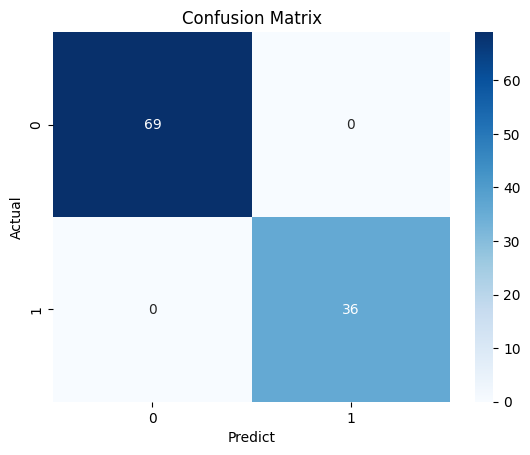

In [43]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()